# <center> ***Projet : Prédiction de la Demande de Vélos en Libre-Service (Bike Sharing Demand)***

# <center> ***Machine learning***

In [1]:
#importation des biliothèques
import pandas as pd 

#importation de nos données 
df = pd.read_csv(r"C:\Users\imazi\OneDrive\Bureau\travail scolaire\programmation\Python\Machine learning\projet-bike-sharing\train_clean.csv")

#verfication
df.head()


,datetime,season,holiday,workingday,weather,atemp,humidity,windspeed,casual,registered,count,hour,year,month
0,2011-01-01 00:00:00,Hiver,jour non férié,week-end/jour férié,Dégagé,14.395,81,0.0,3,13,16,0,2011,1
1,2011-01-01 01:00:00,Hiver,jour non férié,week-end/jour férié,Dégagé,13.635,80,0.0,8,32,40,1,2011,1
2,2011-01-01 02:00:00,Hiver,jour non férié,week-end/jour férié,Dégagé,13.635,80,0.0,5,27,32,2,2011,1
3,2011-01-01 03:00:00,Hiver,jour non férié,week-end/jour férié,Dégagé,14.395,75,0.0,3,10,13,3,2011,1
4,2011-01-01 04:00:00,Hiver,jour non férié,week-end/jour férié,Dégagé,14.395,75,0.0,0,1,1,4,2011,1


**Préparation au Machine Learning** 

   Afin de se préparer au Machine Learning, le jeu de données a été assaini. Nous allons à présent crée deux nouveaux tableaux $X$ et $y$ où $X$ est la matrice des caractéristiques et $y$ notre variable cible. Pour prévenir tout risque de fuite de données (Target Leakage), les variables redondantes avec notre cible finale (casual et registered) ont été supprimées de $X$.De plus, la variable **datetime** est suprimée car redondante par rapport à nos variables *hour, month, year*. 

In [2]:
X = df.drop(columns=['count','datetime','casual','registered'])
y = df['count']

In [3]:
#Regardons nos données
X.head()

,season,holiday,workingday,weather,atemp,humidity,windspeed,hour,year,month
0,Hiver,jour non férié,week-end/jour férié,Dégagé,14.395,81,0.0,0,2011,1
1,Hiver,jour non férié,week-end/jour férié,Dégagé,13.635,80,0.0,1,2011,1
2,Hiver,jour non férié,week-end/jour férié,Dégagé,13.635,80,0.0,2,2011,1
3,Hiver,jour non férié,week-end/jour férié,Dégagé,14.395,75,0.0,3,2011,1
4,Hiver,jour non férié,week-end/jour férié,Dégagé,14.395,75,0.0,4,2011,1


Comme vu ci-dessus, on voit que les valeurs que prennent les variables *season, holiday, workingday, weather* sont des chaînes de caractère et non des nombres. En effet, pendant notre phase d'exploration (EDA), nous avions transformé les chiffres (1, 2, 3, 4) en texte ("Printemps", "Été", "Dégagé", "Pluie") pour que nos graphiques soient beaux et lisibles par des humains. Cependant, les algorithmes de machines leaning sont souvent incapable de lire le texte. Nous pourrions remettre 1 pour Printemps, 2 pour Été, etc. Cependant, cela engendre un risque de créer un ordre mathématique entre les saisons (*Printemps < Eté*), ce qui est absurde. Nous allons à la place créer autant de colonnes que de modalités possibles pour nos variables dont la valeurs serait soit 0 (la modalité n'est pas représenteée sur cette observation) ou 1 (la modalité est représentée). **Exemple**: pour une colonne comme *season* qui a 4 possibilités, Pandas va créer **4 nouvelles colonnes** (season_Printemps, season_Hiver, etc.) remplies de 0 et de 1 (Vrai ou Faux).

In [4]:
# On utilise pandas pour cela
X = pd.get_dummies(X, drop_first=True)

Notre matrice de caractéristiques ($X$) et notre cible (*count*) sont désormais prêtes à être modélisées. 

Commençons par séparer nos tableaux $X$ et $y$  en **deux groupes**: un groupe d'**entraînement** (80% de notre dataset) qui servira à entraîner le modèles et d'affiner ses hyperparamètres et de **test** (20% de notre dataset) qui servira à tester notre modèle sur des données inconnue lors de la phase d'entrainement.

In [5]:
# nous utilisons pour cela la bibliothèque skit-learn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)
#random_state sert à avoir de l'aléatoire reproductible

Pour étoffer notre démarche, nous allons tester plusieurs modèles de régressions sur nos données et en séléctionner le meilleur, expliquant à chaque fois le principe de l'algorithme. Mais pour cela, nous allons avoir besoins d'outils de comparaison des modèles, pour cela, nous utiliserons différentes métriques.

## Les métriques d'évaluation

Une métrique d'évaluation est une mesure quantifiable permettant d'évaluer les performances d'un modèle de machine learning. Il s'agit d'un moyen de vérifier les performances d'un modèle, c'est-à-dire à quel point les valeurs prédites sont proches des valeurs réelles pour les données test. Les métriques que nous allons utilisés seront les mêmes pour tous nos modèles afin de garentir un sens à nos comparaisons, ils sont introduites ci_dessous.

- *la moyenne de la valeur absolue des erreurs* (mean aboulute error ou **MAE**). Mathématiquement,
   on a que $MAE = \frac{1}{m}\sum\limits_{j=1}^m |y_{pred_j} - y_{test_i}|$ où $m$ correspond au nombre total d'observations, elle correspond donc à 'écart moyen entre prédiction et réalité.
  
- *la racine de l'erreur quadratique moyenne* (Root Mean Squared Error ou RMSE). Mathématiquement, 
  on a que $RMSE = \sqrt{\frac{1}{m}\sum\limits_{j=1}^m (y_{pred_j} - y_{test_j})^2}$. Contrairement à la MAE, cette métrique élève les erreurs au carré avant d'en calculer la moyenne. Cela a pour effet de pénaliser beaucoup plus lourdement les grandes erreurs de prédiction, nous alertant ainsi si le modèle est parfois complètement "à côté de la plaque".

- la racine de l'erreur quadratique moyenne logarithmique (Root Mean Squared Logarithmic Error ou RMSLE). Mathématiquement, on a que $RMSLE = \sqrt{\frac{1}{m}\sum\limits_{j=1}^m (\log(y_{pred_j} + 1) - \log(y_{test_j} + 1))^2}$. Cette métrique est particulièrement adaptée lorsque la cible à prédire présente de grandes disparités (des jours à 10 vélos et des jours à 1000 vélos). En appliquant un logarithme, la métrique évalue l'erreur relative (le ratio) plutôt que l'erreur absolue. Le terme "+ 1" est ajouté mathématiquement pour éviter de calculer le logarithme de zéro. Enfin, une particularité métier du RMSLE est qu'il pénalise plus lourdement une sous-estimation (prévoir moins de vélos que la réalité) qu'une surestimation.

- *Le coefficient de détermination ($R^2$)*. Mathématiquement, la formule est $R^2 = 1 - \frac{\sum\limits_{j=1}^m (y_{test_j} - y_  {pred_j})^2}{\sum\limits_{j=1}^m (y_{test_j} - \bar{y}_{test})^2}$,où $\bar{y}_{test}$ correspond à la moyenne des vraies valeurs. Plus qu'une erreur, c'est un score global d'évaluation. Un $R^2$ de $1.0$ correspond à un modèle qui prédit parfaitement la réalité, tandis qu'un score de $0.0$ signifie que le modèle n'est pas plus intelligent que si l'on prédisait toujours la moyenne des locations, quelles que soient les conditions.

In [6]:
# importations des différentes métriques
from sklearn.metrics import r2_score, mean_absolute_error,root_mean_squared_error, root_mean_squared_log_error 

## Modèle d'arabre de décision 

### Introduction à l'Arbre de Décision (Decision Tree)

L'Arbre de Décision fonctionne exactement comme une partie du jeu "Qui est-ce ?" ou comme un grand logigramme de questions vrai/faux.

L'algorithme va observer nos données d'entraînement et chercher la question qui sépare le mieux nos données pour deviner le nombre de vélos. Par exemple, sa première question (la racine de l'arbre) pourrait être : "Est-ce qu'il est plus de 7h du matin ?".

- Si Oui, il part sur une branche et pose une autre question : "Est-ce un jour de travail ?"

- Si Non, il part sur une autre branche : "Fait-il plus de 10°C ?"

Il continue de diviser nos données en posant des questions sur nos variables ($X$) jusqu'à arriver au bout d'une branche (qu'on appelle une "feuille"). Dans le cas d'un problème de Régression comme le nôtre, la valeur finale de cette feuille sera **la moyenne des vélos loués pour toutes les heures** d'entraînement qui ont répondu exactement à ce chemin de questions. C'est un algorithme très visuel, rapide, et qui imite en quelque sorte le raisonnement humain.

In [7]:
# 1. Importation du modèle de régression
from sklearn.tree import DecisionTreeRegressor

# 2. Instanciation du modèle (on fixe le hasard pour avoir les mêmes résultats)
arbre_model = DecisionTreeRegressor(random_state=42)

# 3. Entraînement de l'algorithme sur nos données d'entraînement
arbre_model.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

### Fiabilité du modèle et pouvoir prédective

Nous allons dans cette partie calculer les différentes métriques d'avaluation du modèle.
On pose *y_pred* les prédictions de notre modèle.

In [8]:
y_pred = arbre_model.predict(X_test)

In [9]:
MAE = mean_absolute_error(y_test,y_pred)
RMSE = root_mean_squared_error(y_test,y_pred)
RMSLE = root_mean_squared_log_error(y_test,y_pred)
R_2 = r2_score(y_test,y_pred)

In [10]:
print("la moyenne de la valeur absolue des erreurs : ",MAE)
print("\n la racine de l'erreur quadratique moyenne : ", RMSE)
print("\n la racine de l'erreur quadratique moyenne logarithmique : ", RMSLE)
print("\n Le coefficient de détermination ($R^2$) : ", R_2)

la moyenne de la valeur absolue des erreurs :  36.02204869085898

 la racine de l'erreur quadratique moyenne :  56.89357373377309

 la racine de l'erreur quadratique moyenne logarithmique :  0.433648651685026

 Le coefficient de détermination ($R^2$) :  0.9051072513838686


Les premiers résultats obtenus par notre modèle d'Arbre de Décision brut sont exceptionnellement encourageants pour une baseline (modèle de référence). Avec un coefficient de détermination ($R^2$) de 0.905, l'algorithme parvient à expliquer plus de 90 % des variations de la demande en vélos. Cela valide indéniablement la qualité du nettoyage de nos données et la pertinence des variables temporelles créées lors du Feature Engineering. D'un point de vue purement opérationnel, l'Erreur Absolue Moyenne (MAE) indique que notre modèle se trompe en moyenne de seulement 36 vélos par prédiction. Pour un gestionnaire de flotte, cette marge d'erreur est tout à fait acceptable pour anticiper les stocks. Le RMSE (56.89), logiquement supérieur au MAE, suggère néanmoins la présence de quelques erreurs isolées plus importantes, probablement lors de pics de demande atypiques.

Toutefois, en Data Science, un score initial aussi élevé avec un Arbre de Décision non contraint doit éveiller notre vigilance. Ce type d'algorithme est en effet connu pour son fort risque de surapprentissage (overfitting) : il a tendance à mémoriser les données d'entraînement dans les moindres détails plutôt qu'à en dégager des règles de généralisation robustes. Avant de valider ce modèle, il est donc indispensable de confronter ces scores de test à ceux obtenus sur les données d'entraînement afin d'évaluer la stabilité réelle de notre IA. Calculons donc ces valeurs.

In [11]:
y_pred_train = arbre_model.predict(X_train)

In [12]:
MAE = mean_absolute_error(y_train,y_pred_train)
RMSE = root_mean_squared_error(y_train,y_pred_train)
RMSLE = root_mean_squared_log_error(y_train,y_pred_train)
R_2 = r2_score(y_train,y_pred_train)

In [13]:
print("la moyenne de la valeur absolue des erreurs : ",MAE)
print("\n la racine de l'erreur quadratique moyenne : ", RMSE)
print("\n la racine de l'erreur quadratique moyenne logarithmique : ", RMSLE)
print("\n Le coefficient de détermination : ", R_2)

la moyenne de la valeur absolue des erreurs :  0.094281120808452

 la racine de l'erreur quadratique moyenne :  2.1114584474668123

 la racine de l'erreur quadratique moyenne logarithmique :  0.011870221902128435

 Le coefficient de détermination :  0.9998627648811337


La confrontation des performances de notre modèle entre le jeu d'entraînement et le jeu de test met en évidence un phénomène classique et  en Machine Learning : le surapprentissage (ou overfitting).Sur nos données d'entraînement, le modèle frôle la perfection absolue avec un coefficient de détermination ($R^2$) de 0.9998 et une erreur (MAE) quasi nulle (0.09 vélo). Cependant, cette performance s'effondre de près de 10 points sur les données de test ($R^2$ de 0.905). Cet écart significatif est la preuve mathématique que notre Arbre de Décision, n'ayant reçu aucune contrainte de profondeur, a grandi de manière excessive. Au lieu d'apprendre la logique métier sous-jacente pour pouvoir la généraliser, l'algorithme s'est contenté de "mémoriser par cœur" nos données d'entraînement, allant jusqu'à créer une règle spécifique pour quasiment chaque observation.Pour corriger ce biais de mémorisation et obtenir un modèle robuste capable de faire de vraies prédictions dans le futur, il est impératif de changer de stratégie. Nous allons donc imposer des limites strictes à la croissance de cet arbre (hyperparamétrage/élagage).

Pour empêcher notre arbre d'apprendre par cœur, nous allons utiliser l'Hyperparamétrage. Pour un arbre de décision, les trois hpyerparamètres les plus importants pour stopper le surapprentissage sont :

max_depth (La profondeur maximale) : On lui interdit de poser plus de X questions à la suite. S'il atteint la limite, il doit s'arrêter et donner sa réponse.

min_samples_split : Le nombre minimum d'observations requises pour avoir le droit de poser une nouvelle question (ex: "S'il reste moins de 20 locations sur cette branche, arrête de diviser !").

min_samples_leaf : Le nombre minimum d'observations qui doivent obligatoirement se trouver à la toute fin d'une branche (dans la "feuille"). Cela empêche l'arbre de créer une règle juste pour 1 seul vélo isolé.

On va pour cela utiliser `GridSearchCV` du module `model_selction`. Cette méthode va tester toutes les conbinaisons possibles des différentes valeurs de nos hyperparamètres et les tester sur une métrique de notre choix (ici, on choisit le R²). La méthode va donc "créer" et tester autant de modèles que de combinaisons. 

In [14]:
from sklearn.model_selection import GridSearchCV


# 1. On définit la grille des réglages que l'on veut tester
parametres_grille = {
    'max_depth': [5, 10, 15, 20, None],       # Différentes profondeurs
    'min_samples_split': [2, 10, 20, 50],     # Minimum pour diviser
    'min_samples_leaf': [1, 5, 10, 20]        # Minimum dans une feuille finale
}

# 2. On instancie un nouvel arbre "vierge"
arbre_a_tuner = DecisionTreeRegressor(random_state=42)

# 3. On configure l'outil de recherche (GridSearch)
recherche = GridSearchCV(
    estimator=arbre_a_tuner,
    param_grid=parametres_grille,
    cv=5,               # Fait 5 tests croisés pour s'assurer que le modèle est stable
    scoring='r2',       # On demande à l'outil de chercher le meilleur R² possible
    n_jobs=-1           # Utilise tous les cœurs de mon processeur pour aller plus vite
)

# 4. Lancement de la recherche 
recherche.fit(X_train, y_train)


print("Les meilleurs paramètres trouvés sont :", recherche.best_params_,)

Les meilleurs paramètres trouvés sont : {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 20}


In [15]:
#Nous allons maintenant lui faire passer le même examen qu'au précédent (le Train et le Test) pour voir si l'écart s'est réduit.

# 1. On récupère notre arbre réglé
meilleur_arbre = recherche.best_estimator_

# 2. On génère les prédictions pour les données d'entraînement (Train) et et de test (est)
y_pred_train_tuned = meilleur_arbre.predict(X_train)
y_pred_test_tuned = meilleur_arbre.predict(X_test)

# 3. On calcule le score R² pour les deux
r2_train_tuned = r2_score(y_train, y_pred_train_tuned)
r2_test_tuned = r2_score(y_test, y_pred_test_tuned)

print(f"Arbre optimisé - Score R² (Entraînement) : {r2_train_tuned:.4f}")
print(f"Arbre optimisé - Score R² (Test) : {r2_test_tuned:.4f}")

Arbre optimisé - Score R² (Entraînement) : 0.9557
Arbre optimisé - Score R² (Test) : 0.9184


#### Comparaison complètes entre les deux modèles 

la moyenne de la valeur absolue des erreurs du modèle optimisé :  34 vélos.

 la racine de l'erreur quadratique moyenne du modèle optimisé :  53 vélos.

 la racine de l'erreur quadratique moyenne logarithmique du modèle optimisé :  0.38.

 Le coefficient de détermination :  0.92.

la moyenne de la valeur absolue des erreurs du modèle sans optimisation :  36 vélos.

 la racine de l'erreur quadratique moyenne sans optimisation :  57 vélos.

 la racine de l'erreur quadratique moyenne logarithmique sans optimisation :  0.43.

 Le coefficient de détermination ($R^2$) sans optimisation :  0.91.

On voit bien que sur toutes les métriques, le modèle optimisé est meilleur.

### Optimisation de l'Arbre de Décision : Résolution du Surapprentissage

L'optimisation des hyperparamètres via une recherche sur grille (GridSearch) nous a permis de corriger efficacement le problème de surapprentissage initial. En imposant des limites structurelles à notre algorithme — notamment une profondeur maximale (max_depth de 15) et un nombre minimum de 20 observations pour autoriser la division d'une branche (min_samples_split) — nous avons forcé le modèle à extraire une logique globale plutôt qu'à mémoriser le jeu de données par cœur.Mathématiquement, ce rééquilibrage se traduit par une baisse saine et attendue de la performance sur les données d'entraînement (le $R^2$ passant de 0.9998 à 0.9557). Libéré de ce biais d'apprentissage par cœur, le modèle se révèle plus performant face à de nouvelles situations, faisant grimper son score sur le jeu de test à 0.9184. L'écart de performance entre l'entraînement et le test est ainsi passé de près de 10 points à moins de 4 points. Nous disposons désormais d'un modèle de base à la fois  performant et robuste pour prédire la demande de vélos.

## La Forêt Aléatoire (Random Forest)

### Introduction aux forêts Aléatoires 

Bien que notre arbre optimisé soit performant, nous passons à la Forêt Aléatoire pour repousser les limites de la précision en combinant plusieurs modèles afin d'annuler leurs erreurs individuelles.

Le fonctionnement de cet algorithme repose sur le concept puissant de la "sagesse de la foule" (appelé **apprentissage ensembliste**). Au lieu de s'en remettre à un seul Arbre de Décision qui risque de faire des erreurs de jugement, la Forêt Aléatoire **va créer et entraîner simultanément une centaine d'arbres de décision différents**. Pour garantir que ces arbres soient **indépendants et complémentaires**, l'algorithme introduit une double dose de hasard : chaque arbre s'entraîne sur un sous-échantillon tiré au sort de nos données (le Bagging) et ne peut utiliser qu'une sélection aléatoire de nos variables (comme la météo, l'heure ou la saison). Ainsi, certains arbres deviendront des experts de la météo, d'autres des experts des heures de pointe. Au moment de réaliser la prédiction finale, chaque arbre de la forêt vote en donnant son estimation du nombre de vélos, et l'algorithme calcule simplement **la moyenne de tous ces résultats**. Cette méthode permet de lisser les anomalies, de bloquer le surapprentissage et d'obtenir une précision redoutable.

In [16]:
# Importation du modèle
from sklearn.ensemble import RandomForestRegressor

#Initalisation du modèle

forest_model = RandomForestRegressor(random_state= 42)

#Entrainement du modèle

forest_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Nous allons à présent évaluer notre modèle sur les différentes métriques.

In [17]:
# On calcule les prédicitions de notre modèle. 
y_pred_forest = forest_model.predict(X_test)

In [18]:
# On calcules les différentes métriques 
MAE = mean_absolute_error(y_test,y_pred_forest)
RMSE = root_mean_squared_error(y_test,y_pred_forest)
RMSLE = root_mean_squared_log_error(y_test,y_pred_forest)
R_2 = r2_score(y_test,y_pred_forest)

#affichons les valeurs: 
print("la moyenne de la valeur absolue des erreurs : ",MAE)
print("\n la racine de l'erreur quadratique moyenne : ", RMSE)
print("\n la racine de l'erreur quadratique moyenne logarithmique : ", RMSLE)
print("\n Le coefficient de détermination : ", R_2)

la moyenne de la valeur absolue des erreurs :  28.300840803202313

 la racine de l'erreur quadratique moyenne :  45.94729127754333

 la racine de l'erreur quadratique moyenne logarithmique :  0.3478520867073144

 Le coefficient de détermination :  0.9381091532530509


### Évaluation de la Forêt Aléatoire 

Le passage à un algorithme ensembliste (Random Forest) marque une amélioration décisive de nos performances. En combinant les prédictions de 100 arbres de décision indépendants, le modèle atteint un coefficient de détermination ($R^2$) de 0.938 sur le jeu de test, signifiant qu'il parvient à expliquer près de 94 % des variations de la demande. Du côté métier, l'erreur absolue moyenne (MAE) est tombée à un niveau record de 28 locations. Cette précision offre une marge d'erreur faible, garantissant à l'entreprise une optimisation fiable de la logistique de ses vélos en fonction de la météo, de l'heure et du calendrier.

Nous allons aussi vérifier si il y a un phénomène de surapprentissage.

In [19]:
y_pred_train = forest_model.predict(X_train)
y_pred_test = forest_model.predict(X_test)

# On calcule les R² 
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

# Affichage des résultats
print(f"🌲 Forêt Aléatoire - Score R² (Entraînement) : {r2_train:.4f}")
print(f"🌲 Forêt Aléatoire - Score R² (Test) : {r2_test:.4f}")


🌲 Forêt Aléatoire - Score R² (Entraînement) : 0.9916
🌲 Forêt Aléatoire - Score R² (Test) : 0.9381


L'évaluation de notre Forêt Aléatoire révèle un score d'entraînement frôlant la perfection avec un $R^2$ de 0.9916, tandis que le score de test s'établit à un excellent 0.9381. À première vue, cet écart d'environ 5 points pourrait faire penser à un retour du surapprentissage, puisque le modèle semble avoir mémorisé une grande partie des données d'entraînement. Cependant, dans le contexte d'une Forêt Aléatoire, ce comportement est tout à fait normal et attendu. Contrairement à un arbre de décision unique où l'overfitting détruit la capacité de prédiction, la Forêt Aléatoire utilise l'overfitting de ses arbres individuels à son avantage : chaque arbre mémorise une partie différente et spécifique des données, mais la mise en commun de leurs résultats (le système de vote) permet d'annuler ces erreurs individuelles. Le résultat sur le jeu de test (93.8 %) prouve que cette stratégie de "sagesse de la foule" généralise bien la réalité, nous offrant un modèle robuste et précis.

Essayons néanmoins d'améliorer ce score d'avantage avec `GridSearchCv`. 
Attention, cette méthode n'est pas gratuite, sur un modèle comme les forêt aléatoires, tester toutes les combinaisons possible à un coût de calcul et donc de temps assez élevé. C'est pourquoi, pour une Forêt Aléatoire, on utilise souvent une grille plus petite et un nombre de cv réduit. On introduit pour cet entraînement, un hyperparamètre important : n_estimators et qui correspond au nombre d'arbres que l'on veut dans la forêt.

In [20]:
parametres_rf = {
    'n_estimators': [50, 100, 150, 200, 250],      # Le nombre d'arbres dans la forêt
    'max_depth': [5, 10, 15, 20, None],         # La profondeur maximale (None = pas de limite)
    'min_samples_split': [2, 3, 5, 10, 20, 25]     # Le minimum d'observations pour diviser
}

# Instanciation de la forêt vierge
rf_a_tuner = RandomForestRegressor(random_state=42)

# Configuration du GridSearchCV (cv=3 pour gagner du temps)
recherche_rf = GridSearchCV(
    estimator=rf_a_tuner,
    param_grid=parametres_rf,
    cv=3,               
    scoring='r2',       
    n_jobs=-1,          # Super important : utilise tous les cœurs de ton processeur !
    verbose=2           # Affiche l'avancement de la recherche
)

# Lancement de la recherche

recherche_rf.fit(X_train, y_train)

# Affichage des meilleurs paramètre pour maximiser le R².

print("Les meilleurs paramètres de la Forêt sont :", recherche_rf.best_params_)


Fitting 3 folds for each of 150 candidates, totalling 450 fits
Les meilleurs paramètres de la Forêt sont : {'max_depth': 20, 'min_samples_split': 3, 'n_estimators': 250}


Le passage de notre algorithme au crible du GridSearchCV nous a permis d'isoler la configuration la plus performante : un comité étendu de 250 arbres (n_estimators), couplé à une profondeur maximale de 20 niveaux (max_depth) et une division autorisée dès 3 observations (min_samples_split). Ces résultats illustrent la spécificité des méthodes ensemblistes. Contrairement à un Arbre de Décision unique que nous devions sévèrement élaguer pour endiguer le surapprentissage, la Forêt Aléatoire s'autorise des arbres profonds et très détaillés. Le "bruit" et le surapprentissage générés par chaque arbre individuel sont ensuite mécaniquement neutralisés par le vote moyen des 250 estimateurs. Cette optimisation nous dote d'un modèle d'une grande finesse, capable de capter les signaux faibles de nos données temporelles et météorologiques tout en garantissant une excellente robustesse de prédiction.

### Evaluation du modèle optimisé

In [21]:
# On récupère la meilleure forêt directement depuis ton GridSearch

meilleure_foret = recherche_rf.best_estimator_


# On calcule les prédictions faites par les modèles 
y_pred_test_rf_opti = meilleure_foret.predict(X_test)

# On calcule les différentes métriques 
MAE = mean_absolute_error(y_test,y_pred_test_rf_opti)
RMSE = root_mean_squared_error(y_test,y_pred_test_rf_opti)
RMSLE = root_mean_squared_log_error(y_test,y_pred_test_rf_opti)
R_2 = r2_score(y_test,y_pred_test_rf_opti)

#affichons les valeurs: 
print("la moyenne de la valeur absolue des erreurs du modèle optimisé : ",MAE)
print("\n la racine de l'erreur quadratique moyenne du modèle optimisé : ", RMSE)
print("\n la racine de l'erreur quadratique moyenne logarithmique du modèle optimisé : ", RMSLE)
print("\n Le coefficient de détermination du modèle optimisé : ", R_2)


la moyenne de la valeur absolue des erreurs du modèle optimisé :  28.178093563395052

 la racine de l'erreur quadratique moyenne du modèle optimisé :  45.79165535021718

 la racine de l'erreur quadratique moyenne logarithmique du modèle optimisé :  0.3480634369163978

 Le coefficient de détermination du modèle optimisé :  0.9385277252827784


Contrairement à l'Arbre de Décision simple qui a vraiment besoin d'être paramétré pour avoir des résultats fiable, la Forêt Aléatoire est réputée pour être bien ajusté dès sa sortie de la boîte. Ses paramètres par défaut (100 arbres, profondeur infinie) donnent presque toujours d'excellents résultats. L'optimisation par GridSearch permet juste de gratter de légères augumentation de performance, ce qui, à l'échelle de millions de locations sur une année, peut tout de même représenter des économies concrètes pour l'entreprise.

## Le modèle de régression Linéaire

### Fonctionnement de l'algorithme

La Régression Linéaire aborde le problème d'une manière totalement différente des algorithmes basés sur des arbres. Au lieu de segmenter les données avec des règles conditionnelles ("Si température > 20°C..."), elle cherche à établir une relation mathématique proportionnelle, continue et globale entre nos variables explicatives (météo, heure, etc.) et notre cible (le nombre de vélos).

L'algorithme va tenter de faire passer un hyperplan (une "ligne droite" multidimensionnelle) au plus près de tous nos points de données. Pour ce faire, il attribue un "poids" (un coefficient) à chaque variable. Mathématiquement, le modèle cherche à définir l'équation $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$, où $\beta_0$ est la valeur de base (l'ordonnée à l'origine) et les différents $\beta$ représentent l'impact de chaque critère (par exemple : +10 vélos pour chaque degré de température supplémentaire, ou -50 vélos s'il pleut). Bien que très facile à interpréter, ce modèle fait une supposition forte : il présume que la relation entre les variables est strictement linéaire. Tester ce modèle nous permettra de vérifier si la complexité de notre jeu de données justifiait réellement l'usage d'algorithmes avancés comme la Forêt Aléatoire.

In [22]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Instanciation du modèle
lr_model = LinearRegression()

# 2. Entraînement du modèle
lr_model.fit(X_train, y_train)

# 3. Prédictions sur l'entraînement et le test
y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

# 4. Calcul des métriques sur le jeu de test
mae_lr = mean_absolute_error(y_test, y_pred_test_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_test_lr)
r2_lr = r2_score(y_test, y_pred_test_lr)

print(f" Régression Linéaire - Score R² : {r2_lr:.4f}")
print(f" Régression Linéaire - MAE : {mae_lr:.2f} vélos")
print(f" Régression Linéaire - RMSE : {rmse_lr:.2f} vélos")

 Régression Linéaire - Score R² : 0.3975
 Régression Linéaire - MAE : 106.43 vélos
 Régression Linéaire - RMSE : 143.36 vélos


### Conclusion sur la Régression Linéaire

L'évaluation d'un modèle de Régression Linéaire simple confirme que la dynamique de location de vélos est profondément non linéaire. Avec un coefficient de détermination ($R^2$) s'effondrant à 0.3975 et une erreur absolue moyenne (MAE) bondissant à plus de 106 vélos, ce modèle paramétrique se révèle incapable de capter les subtilités de nos données. Les variations cycliques (pics d'utilisation à certaines heures précises, effets non proportionnels des saisons ou de la météo) ne peuvent être modélisées par une simple équation linéaire. Cet essai justifie et valide définitivement notre choix final : l'utilisation d'un algorithme ensembliste non linéaire comme la Forêt Aléatoire, qui reste notre modèle vainqueur et définitif.

##  Décryptage des décisions du modèle : L'importance des variables

Dans cette partie, nous allons voir quels sont les variables qui influence le plus les personnes pour louer un vélo

C:\Users\imazi\AppData\Local\Temp\ipykernel_14028\2730481567.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importances.head(10), palette='viridis')


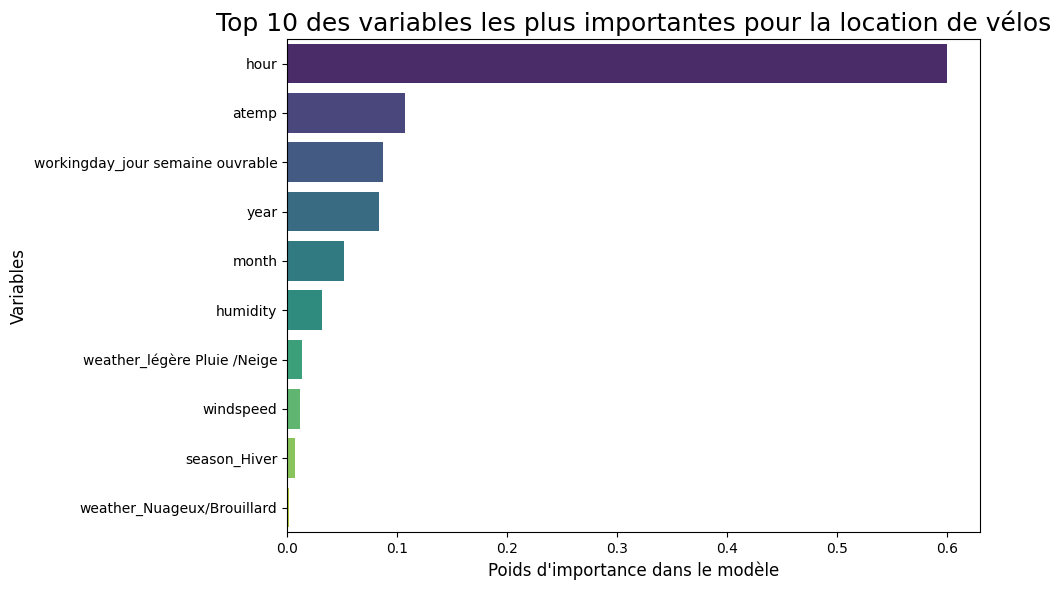

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. On extrait l'importance calculée par la forêt et le nom des colonnes
importances = meilleure_foret.feature_importances_
noms_variables = X_train.columns

# 2. On crée un tableau Pandas pour trier tout ça du plus grand au plus petit
df_importances = pd.DataFrame({'Variable': noms_variables, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False)

# 3. On trace un beau graphique avec Seaborn pour le Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=df_importances.head(10), palette='viridis')
plt.title('Top 10 des variables les plus importantes pour la location de vélos', fontsize=18)
plt.xlabel("Poids d'importance dans le modèle", fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()

L'analyse de l'importance des variables extraite de notre Forêt Aléatoire révèle de manière limpide les véritables moteurs de la demande de vélos. Le constat est sans appel : la variable hour (l'heure de la journée) domine le processus de décision de l'algorithme, pesant à elle seule pour environ 60 % des prédictions. Cela confirme que la location de vélos est avant tout une question de rythme pendulaire, dictée par les horaires de bureau et d'école. Loin derrière cette hégémonie de l'horloge, le confort de l'utilisateur s'impose comme le deuxième critère le plus décisif avec la température ressentie (atemp), suivi logiquement par la nature du jour (workingday, qui distingue les jours ouvrés des week-ends). On remarque également que la variable year joue un rôle non négligeable, prouvant que le modèle a su capter la forte croissance de popularité du service entre 2011 et 2012. Pour un gestionnaire de flotte, ce graphique est une véritable feuille de route actionnable : si la météo influence ponctuellement l'affluence, c'est avant tout l'horloge quotidienne qui doit dicter le rééquilibrage logistique des stations.

In [24]:
import joblib

# On sauvegarde notre forêt optimisée dans un fichier
joblib.dump(meilleure_foret, 'modele_foret_velo.joblib', compress=3)

print("✅ Modèle sauvegardé avec succès sous 'modele_foret_velo.joblib' !")

✅ Modèle sauvegardé avec succès sous 'modele_foret_velo.joblib' !
